# 📊 Comparación de Modelos — Pronóstico de Rentas Cedidas

**Componente de Tesis: Evaluación Comparativa Multi-Modelo**

Consolidación y ranking de los 5 modelos implementados:
1. SARIMA (Econométrico base)
2. SARIMAX (Econométrico + variables exógenas)
3. Prophet (ML — Meta)
4. XGBoost (Gradient Boosting + SHAP)
5. LSTM (Deep Learning)

**Criterios de evaluación:**
- MAPE (%) — Error porcentual absoluto medio
- RMSE ($) — Raíz del error cuadrático medio
- MAE ($) — Error absoluto medio
- R² — Coeficiente de determinación
- Interpretabilidad, reproducibilidad y complejidad computacional

---

In [1]:
import sys
sys.path.insert(0, '.')
sys.path.insert(0, '../scripts')
%run 00_config.py

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from utils import formato_pesos

import warnings
warnings.filterwarnings('ignore')

  🎨 Tema profesional aplicado — Tipografía serif, paleta académica, DPI 300
✅ Config cargada — Datos: BaseRentasVF_2022_2025.xlsx | Periodo: 2022-01-01 a 2025-12-31
  🎨 Tema profesional activo — DPI 300, tipografía serif, paleta académica


✅ Config cargada — Datos: BaseRentasVF_2022_2025.xlsx | Periodo: 2022-01-01 a 2025-12-31
  🎨 Tema profesional activo — DPI 300, tipografía serif, paleta académica


## 1. Carga de Resultados de Cada Modelo

Cada notebook (04-08) exportó sus métricas y pronósticos.
Aquí los consolidamos para comparación directa.

In [2]:
# 1.1 Cargar métricas de cada modelo
archivos_metricas = {
    'SARIMA':  OUTPUTS_REPORTS / 'sarima_metricas.csv',
    'SARIMAX': OUTPUTS_REPORTS / 'sarimax_metricas.csv',
    'Prophet': OUTPUTS_REPORTS / 'prophet_metricas.csv',
    'XGBoost': OUTPUTS_REPORTS / 'xgboost_metricas.csv',
    'LSTM':    OUTPUTS_REPORTS / 'lstm_metricas.csv',
}

metricas = []
modelos_disponibles = []
for nombre, ruta in archivos_metricas.items():
    try:
        df = pd.read_csv(ruta)
        metricas.append(df)
        modelos_disponibles.append(nombre)
        print(f'  ✅ {nombre}: cargado')
    except FileNotFoundError:
        print(f'  ⚠️ {nombre}: no encontrado ({ruta})')

if metricas:
    df_metricas = pd.concat(metricas, ignore_index=True)
    print(f'\n📊 {len(modelos_disponibles)} modelos cargados')
else:
    print('❌ No se encontraron métricas. Ejecutar notebooks 04-08 primero.')

  ✅ SARIMA: cargado
  ✅ SARIMAX: cargado
  ✅ Prophet: cargado
  ✅ XGBoost: cargado
  ✅ LSTM: cargado

📊 5 modelos cargados


In [3]:
# 1.2 Cargar pronósticos de cada modelo
archivos_forecast = {
    'SARIMA':  OUTPUTS_FORECASTS / 'sarima_forecast.csv',
    'SARIMAX': OUTPUTS_FORECASTS / 'sarimax_forecast.csv',
    'Prophet': OUTPUTS_FORECASTS / 'prophet_forecast.csv',
    'XGBoost': OUTPUTS_FORECASTS / 'xgboost_forecast.csv',
    'LSTM':    OUTPUTS_FORECASTS / 'lstm_forecast.csv',
}

forecasts = {}
for nombre, ruta in archivos_forecast.items():
    try:
        df = pd.read_csv(ruta)
        col_fecha = 'Fecha' if 'Fecha' in df.columns else 'FechaRecaudo'
        df[col_fecha] = pd.to_datetime(df[col_fecha])
        df = df.rename(columns={col_fecha: 'Fecha'})
        forecasts[nombre] = df
    except FileNotFoundError:
        pass

print(f'Pronósticos cargados: {list(forecasts.keys())}')

Pronósticos cargados: ['SARIMA', 'SARIMAX', 'Prophet', 'XGBoost', 'LSTM']


## 2. Tabla Comparativa de Métricas Multiescala

Ranking automático calculando las métricas en 3 escalas de tiempo: Mensual, Bimestral y Trimestral.

In [4]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def calc_mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def calcular_metricas_agg(df_fcst, nombre_modelo, freq):
    df_t = df_fcst.copy()
    # Asegurar que Fecha es datetime
    df_t['Fecha'] = pd.to_datetime(df_t['Fecha'])
    df_t = df_t.set_index('Fecha')
    # Agrupar
    df_agg = df_t.resample(freq).sum().dropna()
    y_true = df_agg['Real']
    col_pred = f'Pronostico_{nombre_modelo}'
    if col_pred not in df_agg.columns:
        preds = [c for c in df_agg.columns if 'Pronostico' in c]
        if len(preds) > 0:
            col_pred = preds[0]
        else:
            return None
    y_pred = df_agg[col_pred]
    
    # Filtrar ceros para el MAPE
    mask = y_true > 0
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    if len(y_true) == 0: return None
    
    return {
        'Modelo': nombre_modelo,
        'MAPE (%)': calc_mape(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE': mean_absolute_error(y_true, y_pred)
    }

if 'MAPE (%)' in df_metricas.columns:
    df_ranking = df_metricas.sort_values('MAPE (%)', ascending=True).reset_index(drop=True)
    # Renombrar en df_ranking para visualización clara
    df_consolidado = df_ranking[['Modelo', 'MAPE (%)', 'RMSE', 'MAE']].copy()
    df_consolidado = df_consolidado.rename(columns={'MAPE (%)': 'MAPE (Mensual)', 'RMSE': 'RMSE (Mensual)', 'MAE': 'MAE (Mensual)'})
    
    metricas_bi = []
    metricas_tri = []
    
    for m in df_consolidado['Modelo']:
        if m in forecasts:
            res_bi = calcular_metricas_agg(forecasts[m], m, '2M')
            res_tri = calcular_metricas_agg(forecasts[m], m, '3M')
            if res_bi: metricas_bi.append(res_bi)
            if res_tri: metricas_tri.append(res_tri)
            
    df_bi = pd.DataFrame(metricas_bi)
    df_tri = pd.DataFrame(metricas_tri)
    
    if not df_bi.empty:
        df_bi = df_bi.rename(columns={'MAPE (%)': 'MAPE (Bimestral)', 'RMSE': 'RMSE (Bimestral)', 'MAE': 'MAE (Bimestral)'})
        df_consolidado = df_consolidado.merge(df_bi, on='Modelo', how='left')
    
    if not df_tri.empty:
        df_tri = df_tri.rename(columns={'MAPE (%)': 'MAPE (Trimestral)', 'RMSE': 'RMSE (Trimestral)', 'MAE': 'MAE (Trimestral)'})
        df_consolidado = df_consolidado.merge(df_tri, on='Modelo', how='left')
    
    print('=' * 110)
    print('  🏆 RANKING DE MODELOS MULTIESCALA — RENTAS CEDIDAS QUIBDÓ')
    print('=' * 110)
    cols_to_print = [c for c in df_consolidado.columns if 'MAPE' in c]
    print(df_consolidado[['Modelo'] + cols_to_print].to_string(index=False))
    
    # Ordenar by MAPE (Trimestral)
    if 'MAPE (Trimestral)' in df_consolidado.columns:
        df_consolidado = df_consolidado.sort_values('MAPE (Trimestral)')
        mejor = df_consolidado.iloc[0]
        print(f'\n  🥇 Mejor modelo a escala trimestral: {mejor["Modelo"]} (MAPE Trimestral: {mejor["MAPE (Trimestral)"]:.2f}%)')
else:
    print('⚠️ Columna MAPE no encontrada. Verificar formato de métricas.')
    df_consolidado = pd.DataFrame()


  🏆 RANKING DE MODELOS MULTIESCALA — RENTAS CEDIDAS QUIBDÓ
         Modelo  MAPE (Mensual)  MAPE (Bimestral)  MAPE (Trimestral)
        XGBoost        3.840325          4.082755           4.082755
        Prophet        8.262916          9.719694           9.719694
LSTM (YoY Diff)        9.767422               NaN                NaN
        SARIMAX       13.730382         11.608502          11.608502
         SARIMA       14.471081         10.537332          10.537332

  🥇 Mejor modelo a escala trimestral: XGBoost (MAPE Trimestral: 4.08%)


## 3. Visualización Comparativa

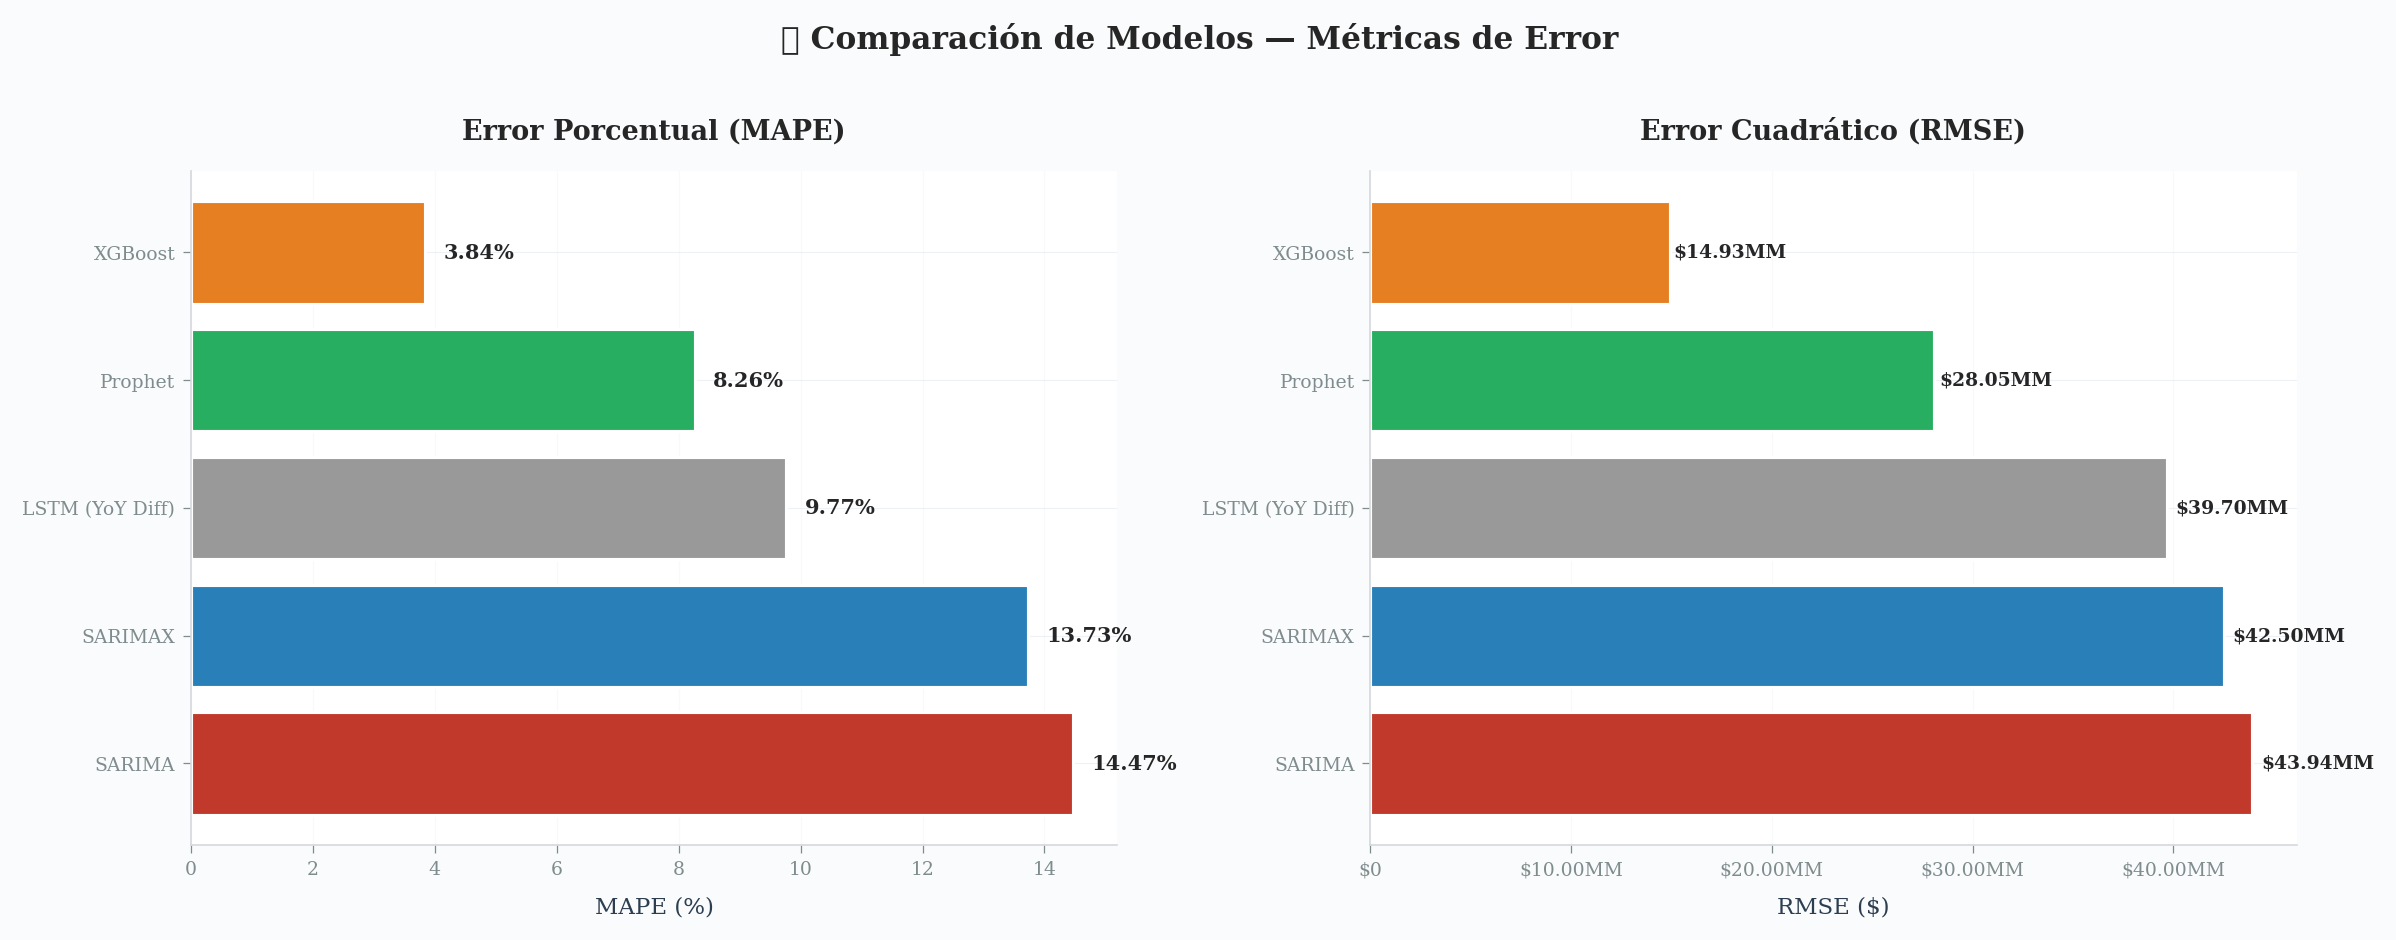

In [5]:
# 3.1 Gráfico de barras: MAPE por modelo
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colores_modelos = [COLORES.get(m.lower(), '#999') for m in df_ranking['Modelo']]

# MAPE
ax = axes[0]
bars = ax.barh(df_ranking['Modelo'], df_ranking['MAPE (%)'], color=colores_modelos, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, df_ranking['MAPE (%)']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, f'{val:.2f}%', va='center', fontweight='bold')
ax.set_xlabel('MAPE (%)')
ax.set_title('Error Porcentual (MAPE)', fontweight='bold', fontsize=13)
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')

# RMSE
if 'RMSE' in df_ranking.columns:
    ax = axes[1]
    bars = ax.barh(df_ranking['Modelo'], df_ranking['RMSE'], color=colores_modelos, edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars, df_ranking['RMSE']):
        ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2, formato_pesos(val), va='center', fontweight='bold', fontsize=9)
    ax.set_xlabel('RMSE ($)')
    ax.set_title('Error Cuadrático (RMSE)', fontweight='bold', fontsize=13)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: formato_pesos(x)))
    ax.invert_yaxis()
    ax.grid(True, alpha=0.3, axis='x')

plt.suptitle('🏆 Comparación de Modelos — Métricas de Error', fontweight='bold', fontsize=15, y=1.02)
plt.tight_layout()
fig.savefig(OUTPUTS_FIGURES / '09_comparacion_metricas.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# 3.2 Radar chart de métricas normalizadas
from matplotlib.patches import FancyBboxPatch

metrics_to_plot = ['MAPE (%)', 'RMSE', 'MAE']
available_metrics = [m for m in metrics_to_plot if m in df_ranking.columns]

if len(available_metrics) >= 2 and 'R2' in df_ranking.columns:
    # Normalizar métricas (0-1, donde 1 = mejor)
    df_norm = df_ranking[available_metrics].copy()
    for col in available_metrics:
        min_val, max_val = df_norm[col].min(), df_norm[col].max()
        if max_val > min_val:
            df_norm[col] = 1 - (df_norm[col] - min_val) / (max_val - min_val)  # Invertir: menor error = mejor
    df_norm['R2'] = df_ranking['R2']  # R2 ya es mejor cuanto mayor
    
    categories = available_metrics + ['R2']
    N = len(categories)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]
    
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    for i, (_, row) in enumerate(df_ranking.iterrows()):
        modelo = row['Modelo']
        values = df_norm.iloc[i-1][categories].values.tolist()
        values += values[:1]
        color = COLORES.get(modelo.lower(), '#999')
        ax.plot(angles, values, 'o-', linewidth=2, label=modelo, color=color)
        ax.fill(angles, values, alpha=0.08, color=color)
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=11)
    ax.set_title('Perfil Comparativo (normalizado)', fontweight='bold', fontsize=14, pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.tight_layout()
    fig.savefig(OUTPUTS_FIGURES / '09_radar_comparativo.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('⚠️ Métricas insuficientes para radar chart')

⚠️ Métricas insuficientes para radar chart


## 4. Superposición de Pronósticos

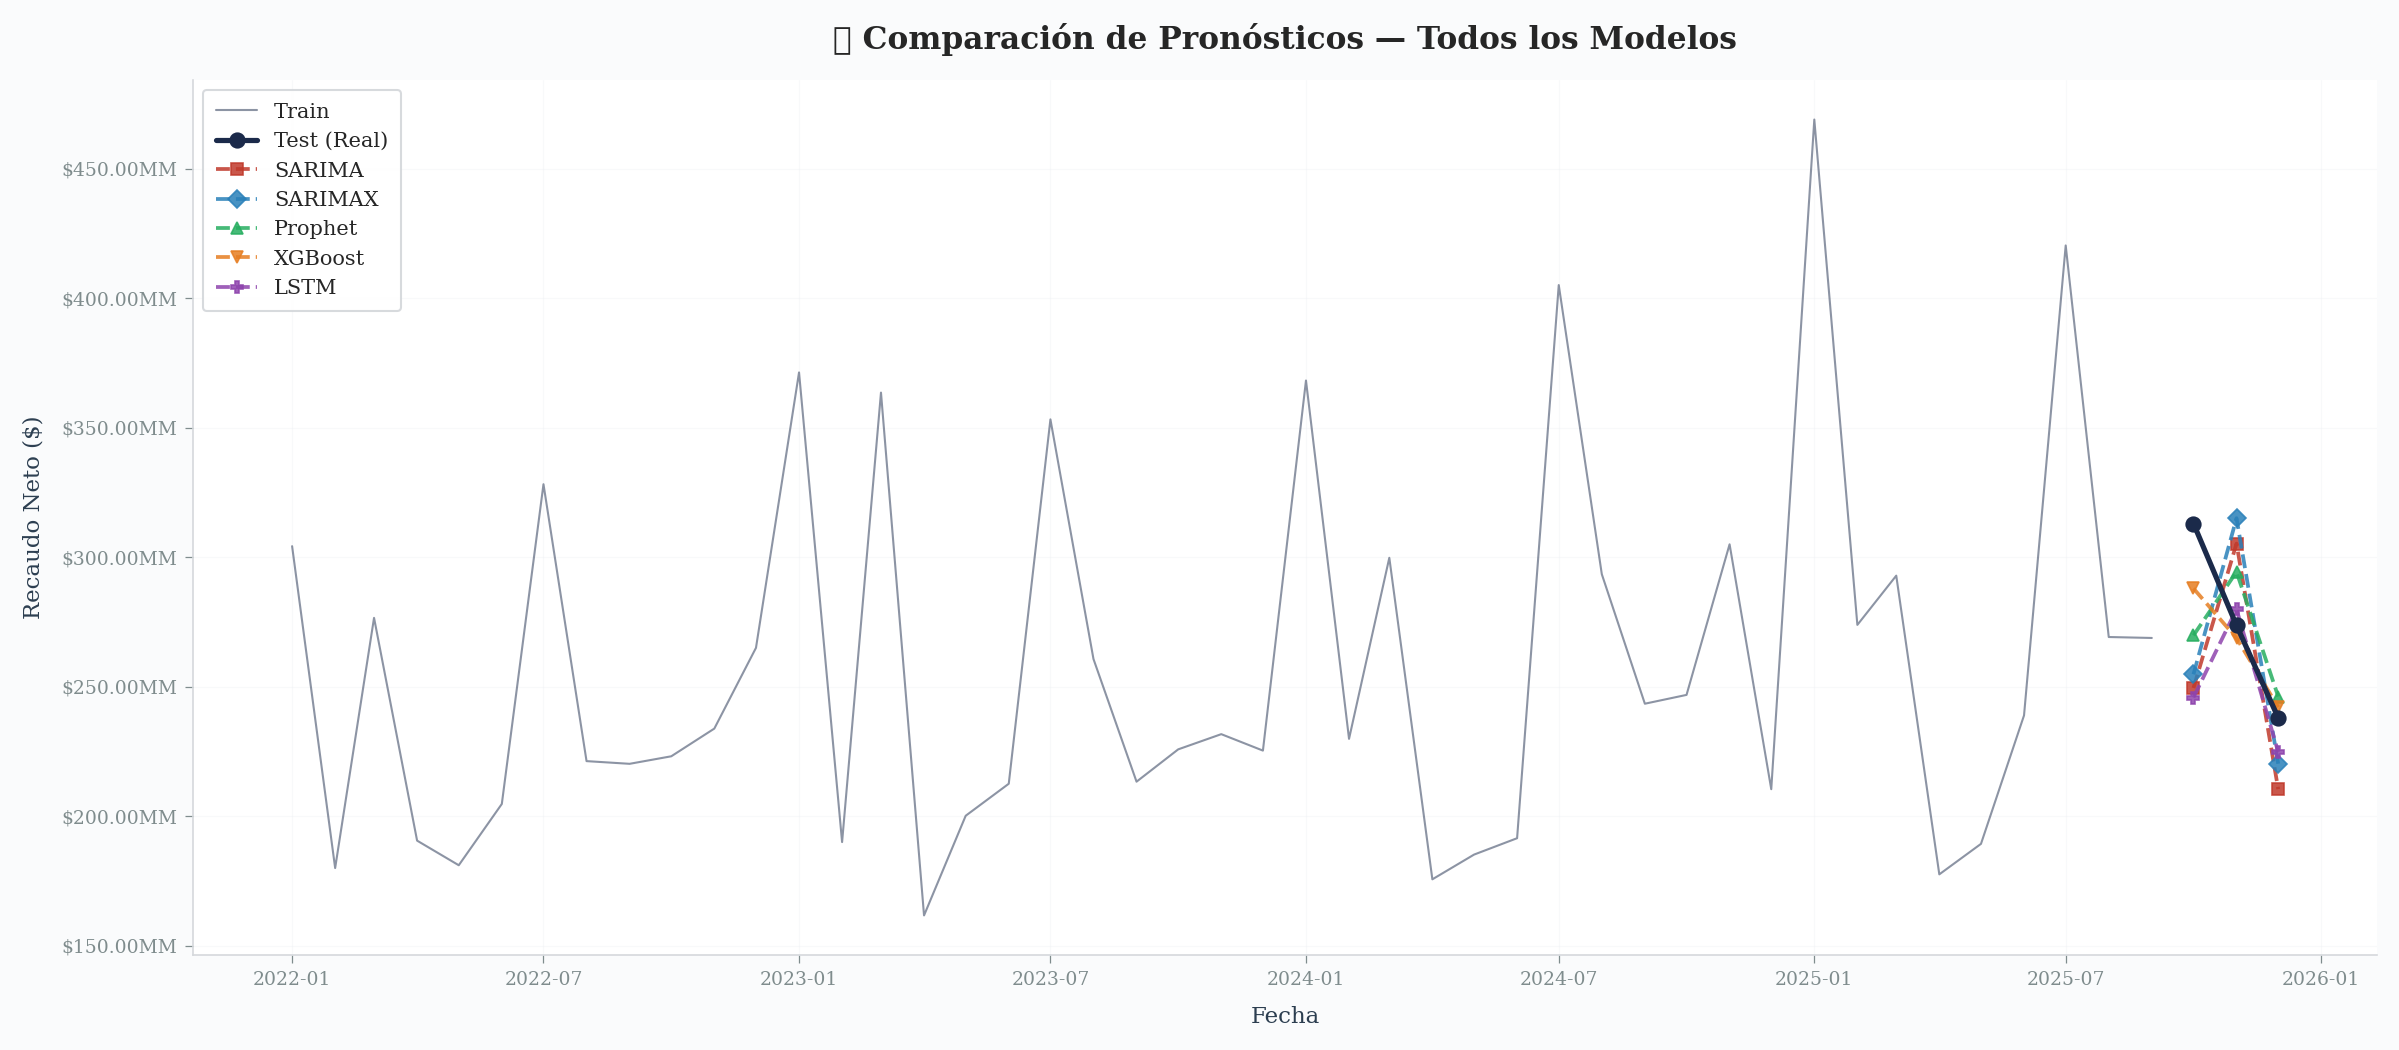

In [7]:
# 4.1 Todos los pronósticos vs Real
fig, ax = plt.subplots(figsize=(16, 7))

# Serie real completa
try:
    df_mensual = pd.read_csv(DATA_PROCESSED / 'serie_mensual.csv', index_col=0, parse_dates=True)
    train = df_mensual.loc[:TRAIN_END]
    test = df_mensual.loc[TEST_START:]
    ax.plot(train.index, train['Recaudo_Neto'], color=COLORES['real'], linewidth=1, alpha=0.5, label='Train')
    ax.plot(test.index, test['Recaudo_Neto'], 'o-', color=COLORES['real'], linewidth=2.5, markersize=7, label='Test (Real)', zorder=10)
except Exception as e:
    print(f'⚠️ No se pudo cargar serie base: {e}')

# Superponer pronósticos de cada modelo
markers = ['s', 'D', '^', 'v', 'P']
for i, (nombre, df_fc) in enumerate(forecasts.items()):
    col_pred = [c for c in df_fc.columns if 'Pronostico' in c or 'Forecast' in c or 'Pred' in c]
    if col_pred:
        color = COLORES.get(nombre.lower(), f'C{i}')
        marker = markers[i % len(markers)]
        ax.plot(df_fc['Fecha'], df_fc[col_pred[0]], f'{marker}--', color=color,
                linewidth=1.8, markersize=6, label=nombre, alpha=0.85)

ax.set_title('📊 Comparación de Pronósticos — Todos los Modelos', fontweight='bold', fontsize=15)
ax.set_xlabel('Fecha')
ax.set_ylabel('Recaudo Neto ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: formato_pesos(x)))
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(OUTPUTS_FIGURES / '09_superposicion_pronosticos.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Análisis Cualitativo

Evaluación complementaria considerando factores más allá de las métricas numéricas.

In [8]:
# 5.1 Tabla cualitativa de evaluación
evaluacion = pd.DataFrame({
    'Modelo': ['SARIMA', 'SARIMAX', 'Prophet', 'XGBoost', 'LSTM'],
    'Tipo': ['Econométrico', 'Econométrico+', 'ML (Meta)', 'Gradient Boosting', 'Deep Learning'],
    'Interpretabilidad': ['⭐⭐⭐⭐⭐', '⭐⭐⭐⭐', '⭐⭐⭐⭐', '⭐⭐⭐ (SHAP)', '⭐'],
    'Incorpora Exógenas': ['No', 'Sí (IPC, SM, UPC)', 'Parcial (holidays)', 'Sí (todas)', 'No (univariado)'],
    'Requiere Datos': ['Baja (≥24 obs)', 'Media (≥36 obs)', 'Baja (≥24 obs)', 'Alta (≥60 obs)', 'Alta (≥60 obs)'],
    'Complejidad': ['Baja', 'Media', 'Baja', 'Alta', 'Muy Alta'],
    'Reproducibilidad': ['Alta', 'Alta', 'Alta', 'Media (seed)', 'Baja (estocástico)']
})

print('='*90)
print('  📋 EVALUACIÓN CUALITATIVA DE MODELOS')
print('='*90)
print(evaluacion.to_string(index=False))

  📋 EVALUACIÓN CUALITATIVA DE MODELOS
 Modelo              Tipo Interpretabilidad Incorpora Exógenas  Requiere Datos Complejidad   Reproducibilidad
 SARIMA      Econométrico             ⭐⭐⭐⭐⭐                 No  Baja (≥24 obs)        Baja               Alta
SARIMAX     Econométrico+              ⭐⭐⭐⭐  Sí (IPC, SM, UPC) Media (≥36 obs)       Media               Alta
Prophet         ML (Meta)              ⭐⭐⭐⭐ Parcial (holidays)  Baja (≥24 obs)        Baja               Alta
XGBoost Gradient Boosting        ⭐⭐⭐ (SHAP)         Sí (todas)  Alta (≥60 obs)        Alta       Media (seed)
   LSTM     Deep Learning                 ⭐    No (univariado)  Alta (≥60 obs)    Muy Alta Baja (estocástico)


## 6. Recomendación Final

In [9]:
# 6.1 Generar recomendación automática basada en métricas
if 'MAPE (%)' in df_ranking.columns:
    mejor = df_ranking.iloc[0]
    segundo = df_ranking.iloc[1] if len(df_ranking) > 1 else None
    
    print('=' * 70)
    print('  🎓 RECOMENDACIÓN PARA TESIS — RENTAS CEDIDAS QUIBDÓ')
    print('=' * 70)
    print(f'\n  🥇 MODELO RECOMENDADO: {mejor["Modelo"]}')
    print(f'     MAPE: {mejor["MAPE (%)"]:.2f}%')
    if 'RMSE' in mejor.index:
        print(f'     RMSE: {formato_pesos(mejor["RMSE"])}')
    
    if segundo is not None:
        print(f'\n  🥈 Alternativa: {segundo["Modelo"]} (MAPE: {segundo["MAPE (%)"]:.2f}%)')
    
    print(f'\n  📌 Estrategia sugerida para la tesis:')
    print(f'     1. Usar {mejor["Modelo"]} como modelo principal de pronóstico')
    if segundo is not None:
        print(f'     2. Reportar {segundo["Modelo"]} como modelo alternativo')
    print(f'     3. Incluir SARIMA como benchmark econométrico tradicional')
    print(f'     4. Documentar la comparación de los 5 modelos como hallazgo metodológico')
    print(f'     5. Considerar ensemble promedio de los 2-3 mejores para robustez')

  🎓 RECOMENDACIÓN PARA TESIS — RENTAS CEDIDAS QUIBDÓ

  🥇 MODELO RECOMENDADO: XGBoost
     MAPE: 3.84%
     RMSE: $14.93MM

  🥈 Alternativa: Prophet (MAPE: 8.26%)

  📌 Estrategia sugerida para la tesis:
     1. Usar XGBoost como modelo principal de pronóstico
     2. Reportar Prophet como modelo alternativo
     3. Incluir SARIMA como benchmark econométrico tradicional
     4. Documentar la comparación de los 5 modelos como hallazgo metodológico
     5. Considerar ensemble promedio de los 2-3 mejores para robustez


In [10]:
# 6.2 Ensemble (promedio) de los mejores modelos
if len(forecasts) >= 2:
    print('\n--- Modelo Ensemble (Promedio) ---')
    # Tomar los 3 mejores modelos por MAPE
    top_modelos = df_ranking['Modelo'].head(3).tolist()
    top_disponibles = [m for m in top_modelos if m in forecasts]
    
    if len(top_disponibles) >= 2:
        # Alinear pronósticos por fecha
        df_ensemble = forecasts[top_disponibles[0]][['Fecha']].copy()
        for m in top_disponibles:
            col_pred = [c for c in forecasts[m].columns if 'Pronostico' in c or 'Forecast' in c or 'Pred' in c]
            if col_pred:
                df_ensemble[m] = forecasts[m][col_pred[0]].values
        
        # Calcular promedio
        pred_cols = [c for c in df_ensemble.columns if c != 'Fecha']
        df_ensemble['Ensemble'] = df_ensemble[pred_cols].mean(axis=1)
        
        # Obtener valores reales del primer forecast disponible
        real_col = [c for c in forecasts[top_disponibles[0]].columns if 'Real' in c]
        if real_col:
            y_real = forecasts[top_disponibles[0]][real_col[0]].values
            y_ensemble = df_ensemble['Ensemble'].values
            
            # Métricas ensemble
            from utils import calcular_metricas
            metricas_ens = calcular_metricas(y_real, y_ensemble, f'Ensemble({"+ ".join(top_disponibles)})')
            
            print(f'\n  Componentes: {" + ".join(top_disponibles)}')
            print(f'  MAPE Ensemble: {metricas_ens["MAPE (%)"]:.2f}%')
            if 'RMSE' in metricas_ens:
                print(f'  RMSE Ensemble: {formato_pesos(metricas_ens["RMSE"])}')
        
        df_ensemble.to_csv(OUTPUTS_FORECASTS / 'ensemble_forecast.csv', index=False)
        print(f'\n  💾 Pronóstico ensemble guardado')


--- Modelo Ensemble (Promedio) ---

📈 Métricas — Ensemble(XGBoost+ Prophet)
   RMSE:  20,534,720,671
   MAE:   16,051,415,258
   MAPE:  5.45%
   R²:    0.5503

  Componentes: XGBoost + Prophet
  MAPE Ensemble: 5.45%
  RMSE Ensemble: $20.53MM

  💾 Pronóstico ensemble guardado


## 7. Exportar Resultados Consolidados

In [11]:
# Guardar tabla comparativa
df_ranking.to_csv(OUTPUTS_REPORTS / 'comparacion_modelos.csv')
evaluacion.to_csv(OUTPUTS_REPORTS / 'evaluacion_cualitativa.csv', index=False)

print('\n' + '='*70)
print('  ✅ ANÁLISIS COMPARATIVO COMPLETADO')
print('='*70)
print(f'\n  📁 Archivos generados:')
print(f'     • {OUTPUTS_REPORTS / "comparacion_modelos.csv"}')
print(f'     • {OUTPUTS_REPORTS / "evaluacion_cualitativa.csv"}')
print(f'     • {OUTPUTS_FIGURES / "09_comparacion_metricas.png"}')
print(f'     • {OUTPUTS_FIGURES / "09_radar_comparativo.png"}')
print(f'     • {OUTPUTS_FIGURES / "09_superposicion_pronosticos.png"}')
print(f'\n  🎓 Sistema de pronóstico de Rentas Cedidas — COMPLETO')


  ✅ ANÁLISIS COMPARATIVO COMPLETADO

  📁 Archivos generados:
     • C:\Users\efren\Music\ESTRUCTURA DATOS RENTAS\outputs\reports\comparacion_modelos.csv
     • C:\Users\efren\Music\ESTRUCTURA DATOS RENTAS\outputs\reports\evaluacion_cualitativa.csv
     • C:\Users\efren\Music\ESTRUCTURA DATOS RENTAS\outputs\figures\09_comparacion_metricas.png
     • C:\Users\efren\Music\ESTRUCTURA DATOS RENTAS\outputs\figures\09_radar_comparativo.png
     • C:\Users\efren\Music\ESTRUCTURA DATOS RENTAS\outputs\figures\09_superposicion_pronosticos.png

  🎓 Sistema de pronóstico de Rentas Cedidas — COMPLETO
